In [1]:
%pip install matplotlib



[notice] A new release of pip is available: 26.0 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd 
import numpy as np
# pyrefly: ignore [missing-import]
import matplotlib.pyplot as plt 
import seaborn as sns 
%matplotlib inline

In [11]:
df = pd.read_csv('/Users/ansartleubayev/Documents/20 projects /data/Almaty_PM2.5.csv')
df.head()

,value,coordinates,location_id,location_name,flagInfo.hasFlags,parameter.id,parameter.name,parameter.units,parameter.displayName,period.label,...,coverage.expectedCount,coverage.expectedInterval,coverage.observedCount,coverage.observedInterval,coverage.percentComplete,coverage.percentCoverage,coverage.datetimeFrom.utc,coverage.datetimeFrom.local,coverage.datetimeTo.utc,coverage.datetimeTo.local
0,91.5,NaN,8876,Almaty,False,2,pm25,µg/m³,NaN,1day,...,24,24:00:00,23,23:00:00,96.0,96.0,2024-12-31T20:00:00Z,2025-01-01T01:00:00+05:00,2025-01-01T19:00:00Z,2025-01-02T00:00:00+05:00
1,23.3,NaN,8876,Almaty,False,2,pm25,µg/m³,NaN,1day,...,24,24:00:00,24,24:00:00,100.0,100.0,2025-01-01T20:00:00Z,2025-01-02T01:00:00+05:00,2025-01-02T19:00:00Z,2025-01-03T00:00:00+05:00
2,73.0,NaN,8876,Almaty,False,2,pm25,µg/m³,NaN,1day,...,24,24:00:00,24,24:00:00,100.0,100.0,2025-01-02T20:00:00Z,2025-01-03T01:00:00+05:00,2025-01-03T19:00:00Z,2025-01-04T00:00:00+05:00
3,52.7,NaN,8876,Almaty,False,2,pm25,µg/m³,NaN,1day,...,24,24:00:00,24,24:00:00,100.0,100.0,2025-01-03T20:00:00Z,2025-01-04T01:00:00+05:00,2025-01-04T19:00:00Z,2025-01-05T00:00:00+05:00
4,30.2,NaN,8876,Almaty,False,2,pm25,µg/m³,NaN,1day,...,24,24:00:00,24,24:00:00,100.0,100.0,2025-01-04T20:00:00Z,2025-01-05T01:00:00+05:00,2025-01-05T19:00:00Z,2025-01-06T00:00:00+05:00


In [ ]:
df.columns

Index(['value', 'coordinates', 'location_id', 'location_name',
       'flagInfo.hasFlags', 'parameter.id', 'parameter.name',
       'parameter.units', 'parameter.displayName', 'period.label',
       'period.interval', 'period.datetimeFrom.utc',
       'period.datetimeFrom.local', 'period.datetimeTo.utc',
       'period.datetimeTo.local', 'summary.min', 'summary.q02', 'summary.q25',
       'summary.median', 'summary.q75', 'summary.q98', 'summary.max',
       'summary.avg', 'summary.sd', 'coverage.expectedCount',
       'coverage.expectedInterval', 'coverage.observedCount',
       'coverage.observedInterval', 'coverage.percentComplete',
       'coverage.percentCoverage', 'coverage.datetimeFrom.utc',
       'coverage.datetimeFrom.local', 'coverage.datetimeTo.utc',
       'coverage.datetimeTo.local'],
      dtype='str')

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 18314 entries, 0 to 18313
Data columns (total 34 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   value                        18314 non-null  float64
 1   coordinates                  0 non-null      float64
 2   location_id                  18314 non-null  int64  
 3   location_name                18314 non-null  str    
 4   flagInfo.hasFlags            18314 non-null  bool   
 5   parameter.id                 18314 non-null  int64  
 6   parameter.name               18314 non-null  str    
 7   parameter.units              18314 non-null  str    
 8   parameter.displayName        0 non-null      float64
 9   period.label                 18314 non-null  str    
 10  period.interval              18314 non-null  str    
 11  period.datetimeFrom.utc      18314 non-null  str    
 12  period.datetimeFrom.local    18314 non-null  str    
 13  period.datetimeTo.utc      

In [ ]:
df.coordinates.isna().sum() # no need for this column 

np.int64(18314)

In [4]:
numeric_df = df.select_dtypes(include='number')
categorical_df = df.select_dtypes(exclude='number') # i guess it's better to say non nummeric but anyway

In [ ]:
numeric_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 18314 entries, 0 to 18313
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   value                     18314 non-null  float64
 1   coordinates               0 non-null      float64
 2   location_id               18314 non-null  int64  
 3   parameter.id              18314 non-null  int64  
 4   parameter.displayName     0 non-null      float64
 5   summary.min               18314 non-null  float64
 6   summary.q02               18314 non-null  float64
 7   summary.q25               18314 non-null  float64
 8   summary.median            18314 non-null  float64
 9   summary.q75               18314 non-null  float64
 10  summary.q98               18314 non-null  float64
 11  summary.max               18314 non-null  float64
 12  summary.avg               18314 non-null  float64
 13  summary.sd                18302 non-null  float64
 14  coverage.expected

In [ ]:
categorical_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 18314 entries, 0 to 18313
Data columns (total 16 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   location_name                18314 non-null  str  
 1   flagInfo.hasFlags            18314 non-null  bool 
 2   parameter.name               18314 non-null  str  
 3   parameter.units              18314 non-null  str  
 4   period.label                 18314 non-null  str  
 5   period.interval              18314 non-null  str  
 6   period.datetimeFrom.utc      18314 non-null  str  
 7   period.datetimeFrom.local    18314 non-null  str  
 8   period.datetimeTo.utc        18314 non-null  str  
 9   period.datetimeTo.local      18314 non-null  str  
 10  coverage.expectedInterval    18314 non-null  str  
 11  coverage.observedInterval    18314 non-null  str  
 12  coverage.datetimeFrom.utc    18314 non-null  str  
 13  coverage.datetimeFrom.local  18314 non-null  str  
 14  c

<Figure size 1800x1000 with 0 Axes>

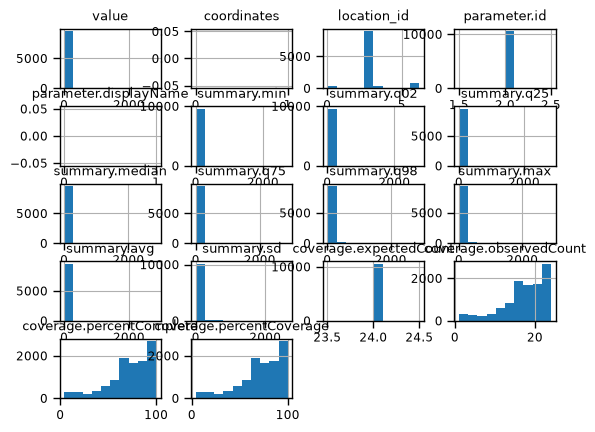

<Figure size 640x480 with 0 Axes>

In [5]:
sns.set_context(font_scale=1, context='paper')
plt.figure(figsize=(18, 10))
df.hist()
plt.show()
plt.tight_layout()

summary.min
0.000000     1790
0.100000      507
0.200000      318
0.300000      283
0.400000      217
             ... 
2.300000        1
0.529167        1
43.600000       1
7.200000        1
42.400000       1
Name: count, Length: 6137, dtype: int64

Breakdown of all the columns from your OpenAQ PM2.5 dataset:
Identification & Location

location_name — Name of the monitoring station
location_id — Unique numeric ID for that station
coordinates — Lat/lon of the station (appears to be empty/null for all rows though)

Parameter Info

parameter.id — Numeric ID of the measured pollutant
parameter.name — Name of the parameter (likely all "pm25" here)
parameter.units — Unit of measurement (probably µg/m³ for PM2.5)
parameter.displayName — Human-readable name (also appears fully null)

Time Period

period.label — A label for the aggregation period (e.g. "2024", "January")
period.interval — Duration of the period (e.g. "P1Y", "P1M" in ISO 8601)
period.datetimeFrom.utc / .local — Start of the measurement window, in UTC and local time
period.datetimeTo.utc / .local — End of the measurement window

Statistical Summary (all for PM2.5 concentration in that period)

value — Likely the primary/representative value (possibly the mean or latest)
summary.min / .max — Minimum and maximum recorded values
summary.q02 / .q25 / .median / .q75 / .q98 — Percentiles (2nd, 25th, 50th, 75th, 98th)
summary.avg — Average concentration
summary.sd — Standard deviation

Data Coverage (how complete the data is for that period)

coverage.expectedCount — How many readings were expected
coverage.observedCount — How many were actually recorded
coverage.percentComplete — % of expected readings that arrived
coverage.percentCoverage — Similar coverage metric (may differ by methodology)
coverage.expectedInterval / .observedInterval — The time resolution expected vs. observed (e.g. "PT1H")
coverage.datetimeFrom / .datetimeTo — The actual time window the coverage calculation spans
flagInfo.hasFlags — Whether any data quality flags were raised for this record

In [7]:
len(df)

10509

0        24:00:00
1        24:00:00
2        24:00:00
3        24:00:00
4        24:00:00
           ...   
10504    24:00:00
10505    24:00:00
10506    24:00:00
10507    24:00:00
10508    24:00:00
Name: period.interval, Length: 10509, dtype: str

In [15]:
df['period.interval'].dtypes

<StringDtype(storage='python', na_value=nan)>

In [9]:
df['period.label'].value_counts()

period.label
1day    10509
Name: count, dtype: int64

In [25]:
df['period.datetimeTo.local'] = pd.to_datetime(df['period.datetimeTo.local'], errors='coerce')
def season_convert(x):
    if pd.isna(x):
        return 'unknown'
    if x in [1,2,12]:
        return 'winter'
    elif x in [3,4,5]:
        return 'spring'
    elif x in [6,7,8]:
        return 'summer'
    else:
        return 'autumn'

In [21]:
df['period.datetimeTo.local']

0       2025-01-02 00:00:00+05:00
1       2025-01-03 00:00:00+05:00
2       2025-01-04 00:00:00+05:00
3       2025-01-05 00:00:00+05:00
4       2025-01-06 00:00:00+05:00
                   ...           
10504   2025-12-29 00:00:00+05:00
10505   2025-12-30 00:00:00+05:00
10506   2025-12-31 00:00:00+05:00
10507   2026-01-01 00:00:00+05:00
10508   2026-01-02 00:00:00+05:00
Name: period.datetimeTo.local, Length: 10509, dtype: datetime64[us, UTC+05:00]

0        24:00:00
1        24:00:00
2        24:00:00
3        24:00:00
4        24:00:00
           ...   
10504    24:00:00
10505    24:00:00
10506    24:00:00
10507    24:00:00
10508    24:00:00
Name: period.interval, Length: 10509, dtype: str

In [26]:
# basically to predict future PM25 values we don't need features about identification&location, parameter info and time periods except the season so we have to create additional feature for it 
df['season'] = df['period.datetimeTo.local'].dt.month.apply(season_convert)
# .month on a Pandas Series (a column), it extracts the month component from each datetime value as an integer from 1 to 12

In [27]:
df.season.value_counts()

season
spring    2978
winter    2939
summer    2868
autumn    1724
Name: count, dtype: int64

In [28]:
df.sample(3)

,value,coordinates,location_id,location_name,flagInfo.hasFlags,parameter.id,parameter.name,parameter.units,parameter.displayName,period.label,...,coverage.expectedInterval,coverage.observedCount,coverage.observedInterval,coverage.percentComplete,coverage.percentCoverage,coverage.datetimeFrom.utc,coverage.datetimeFrom.local,coverage.datetimeTo.utc,coverage.datetimeTo.local,season
9968,76.2,NaN,6175397,Sairan (Qarasai Batyr k-si),False,2,pm25,µg/m³,NaN,1day,...,24:00:00,22,22:00:00,92.0,92.0,2025-12-29T20:00:00Z,2025-12-30T01:00:00+05:00,2025-12-30T18:00:00Z,2025-12-30T23:00:00+05:00,winter
1791,44.3,NaN,2812632,Elaman 105 St.,False,2,pm25,µg/m³,NaN,1day,...,24:00:00,3,03:00:00,13.0,13.0,2025-02-02T19:01:12Z,2025-02-03T00:01:12+05:00,2025-02-03T08:59:19Z,2025-02-03T13:59:19+05:00,winter
1647,14.1,NaN,2812620,Alatau,False,2,pm25,µg/m³,NaN,1day,...,24:00:00,14,14:00:00,58.0,58.0,2025-06-27T19:09:20Z,2025-06-28T00:09:20+05:00,2025-06-28T18:45:25Z,2025-06-28T23:45:25+05:00,summer


In [32]:
df.columns

Index(['value', 'coordinates', 'location_id', 'location_name',
       'flagInfo.hasFlags', 'parameter.id', 'parameter.name',
       'parameter.units', 'parameter.displayName', 'period.label',
       'period.interval', 'period.datetimeFrom.utc',
       'period.datetimeFrom.local', 'period.datetimeTo.utc',
       'period.datetimeTo.local', 'summary.min', 'summary.q02', 'summary.q25',
       'summary.median', 'summary.q75', 'summary.q98', 'summary.max',
       'summary.avg', 'summary.sd', 'coverage.expectedCount',
       'coverage.expectedInterval', 'coverage.observedCount',
       'coverage.observedInterval', 'coverage.percentComplete',
       'coverage.percentCoverage', 'coverage.datetimeFrom.utc',
       'coverage.datetimeFrom.local', 'coverage.datetimeTo.utc',
       'coverage.datetimeTo.local', 'season'],
      dtype='str')

In [40]:
# okay here is the data that doesn't make any sense to our goal 2 of them are even have no values at all 
# basically to predict future PM25 values we don't need features about identification&location(except location name), parameter info and time periods except the season so we have to create additional feature for it 
clean_df = df.drop(columns=['coordinates', 'parameter.displayName', 'location_id', 'parameter.id', 'parameter.name', 'parameter.units', 'parameter.displayName', 'parameter.displayName', 'period.label', 'period.interval', 'period.datetimeFrom.local', 'period.datetimeTo.utc', 'period.datetimeTo.local', 'period.datetimeFrom.utc', 'coverage.datetimeFrom.utc', 'coverage.datetimeFrom.local', 'coverage.datetimeTo.utc', 'coverage.datetimeTo.local']) 

In [41]:
clean_df.sample(3)

,value,location_name,flagInfo.hasFlags,summary.min,summary.q02,summary.q25,summary.median,summary.q75,summary.q98,summary.max,summary.avg,summary.sd,coverage.expectedCount,coverage.expectedInterval,coverage.observedCount,coverage.observedInterval,coverage.percentComplete,coverage.percentCoverage,season
4323,84.80,169 School,True,14.7525,15.046317,18.780625,22.830000,110.906250,367.198833,437.8650,84.825000,392.277140,24,24:00:00,19,19:00:00,79.0,79.0,spring
3440,9.78,KBTU,False,5.5600,5.612200,6.663333,7.836667,10.823333,21.379600,22.6675,9.778684,4.717528,24,24:00:00,19,19:00:00,79.0,79.0,spring
1007,18.10,Kokzhiyek-63,False,7.8100,8.047000,10.157500,14.207500,26.817500,32.008000,32.0300,18.050677,9.347333,24,24:00:00,16,16:00:00,67.0,67.0,summer


In [42]:
clean_df.isna().sum()

value                        928
location_name                  0
flagInfo.hasFlags              0
summary.min                  928
summary.q02                  928
summary.q25                  928
summary.median               928
summary.q75                  928
summary.q98                  928
summary.max                  928
summary.avg                  928
summary.sd                   100
coverage.expectedCount         0
coverage.expectedInterval      0
coverage.observedCount         0
coverage.observedInterval      0
coverage.percentComplete       0
coverage.percentCoverage       0
season                         0
dtype: int64

In [48]:
try_df = clean_df.dropna()
len(try_df)

9485

In [46]:
clean_df.loc[:, 'flagInfo.hasFlags'].value_counts()

flagInfo.hasFlags
False    9344
True     1165
Name: count, dtype: int64

In [ ]:
clean_df[clean_df['value'].isna()]
# hmmm

,value,location_name,flagInfo.hasFlags,summary.min,summary.q02,summary.q25,summary.median,summary.q75,summary.q98,summary.max,summary.avg,summary.sd,coverage.expectedCount,coverage.expectedInterval,coverage.observedCount,coverage.observedInterval,coverage.percentComplete,coverage.percentCoverage,season
2658,NaN,Shamiyeva St.,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,32.944618,24,24:00:00,20,20:00:00,83.0,83.0,autumn
2659,NaN,Shamiyeva St.,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19.441445,24,24:00:00,17,17:00:00,71.0,71.0,autumn
2660,NaN,Shamiyeva St.,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.093166,24,24:00:00,14,14:00:00,58.0,58.0,autumn
2661,NaN,Shamiyeva St.,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,26.464642,24,24:00:00,14,14:00:00,58.0,58.0,autumn
2662,NaN,Shamiyeva St.,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24.545498,24,24:00:00,22,22:00:00,92.0,92.0,autumn
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8743,NaN,"Road, Almaty Industrial Zone",True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,32.699282,24,24:00:00,23,23:00:00,96.0,96.0,autumn
8744,NaN,"Road, Almaty Industrial Zone",True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,37.545753,24,24:00:00,11,11:00:00,46.0,46.0,autumn
9210,NaN,Shkola-Gimnaziya 152,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24,24:00:00,1,01:00:00,4.0,4.0,summer
9275,NaN,Ippodrom,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24,24:00:00,1,01:00:00,4.0,4.0,spring


In [56]:
try_x = [
    "summary.min",
    "summary.q02",
    "summary.q25",
    "summary.median",
    "summary.q75",
    "summary.q98",
    "summary.max",
    "summary.avg"
]


In [57]:
cond_value_na = clean_df['value'].isna()
cond_others_na = clean_df[try_x].isna().all(axis=1)

len(clean_df[cond_value_na & cond_others_na])

928

In [58]:
try_x2 = [
    "summary.min",
    "summary.q02",
    "summary.q25",
    "summary.median",
    "summary.q75",
    "summary.q98",
    "summary.max",
    "summary.avg",
    'value'
]

In [59]:
cond_value_na = clean_df['summary.sd'].isna()
cond_others_na = clean_df[try_x].isna().all(axis=1)

len(clean_df[cond_value_na & cond_others_na])

4

In [65]:

clean_df['summary.sd'].fillna(0, inplace=True)

/var/folders/yl/8sl01vps7blgc_9cthr6pmg80000gn/T/ipykernel_42458/976218287.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  clean_df['summary.sd'].fillna(0, inplace=True)


0        61.092826
1         1.500000
2         1.414214
3        14.988885
4         4.123106
           ...    
10504    48.004945
10505    18.966318
10506    37.262618
10507    68.274598
10508    16.774803
Name: summary.sd, Length: 10509, dtype: float64

In [66]:
clean_df.isna().sum()

value                        928
location_name                  0
flagInfo.hasFlags              0
summary.min                  928
summary.q02                  928
summary.q25                  928
summary.median               928
summary.q75                  928
summary.q98                  928
summary.max                  928
summary.avg                  928
summary.sd                   100
coverage.expectedCount         0
coverage.expectedInterval      0
coverage.observedCount         0
coverage.observedInterval      0
coverage.percentComplete       0
coverage.percentCoverage       0
season                         0
dtype: int64

In [70]:
clean_df = clean_df.dropna(subset=['summary.sd'])

In [ ]:
clean_df['summary.sd'].fillna = clean_df['summary.sd'].fillna(0)


value                       0
location_name               0
flagInfo.hasFlags           0
summary.min                 0
summary.q75                 0
summary.max                 0
summary.avg                 0
summary.sd                  0
coverage.percentCoverage    0
season                      0
dtype: int64

In [73]:
clean_df = clean_df.dropna()

In [76]:
clean_df.isna().sum()

value                        0
location_name                0
flagInfo.hasFlags            0
summary.min                  0
summary.q02                  0
summary.q25                  0
summary.median               0
summary.q75                  0
summary.q98                  0
summary.max                  0
summary.avg                  0
summary.sd                   0
coverage.expectedCount       0
coverage.expectedInterval    0
coverage.observedCount       0
coverage.observedInterval    0
coverage.percentComplete     0
coverage.percentCoverage     0
season                       0
dtype: int64

In [77]:
clean_df.info()

<class 'pandas.DataFrame'>
Index: 9485 entries, 0 to 10508
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   value                      9485 non-null   float64
 1   location_name              9485 non-null   str    
 2   flagInfo.hasFlags          9485 non-null   bool   
 3   summary.min                9485 non-null   float64
 4   summary.q02                9485 non-null   float64
 5   summary.q25                9485 non-null   float64
 6   summary.median             9485 non-null   float64
 7   summary.q75                9485 non-null   float64
 8   summary.q98                9485 non-null   float64
 9   summary.max                9485 non-null   float64
 10  summary.avg                9485 non-null   float64
 11  summary.sd                 9485 non-null   float64
 12  coverage.expectedCount     9485 non-null   int64  
 13  coverage.expectedInterval  9485 non-null   str    
 14  coverag

In [81]:
df.value.mean()

np.float64(39.66697320947709)

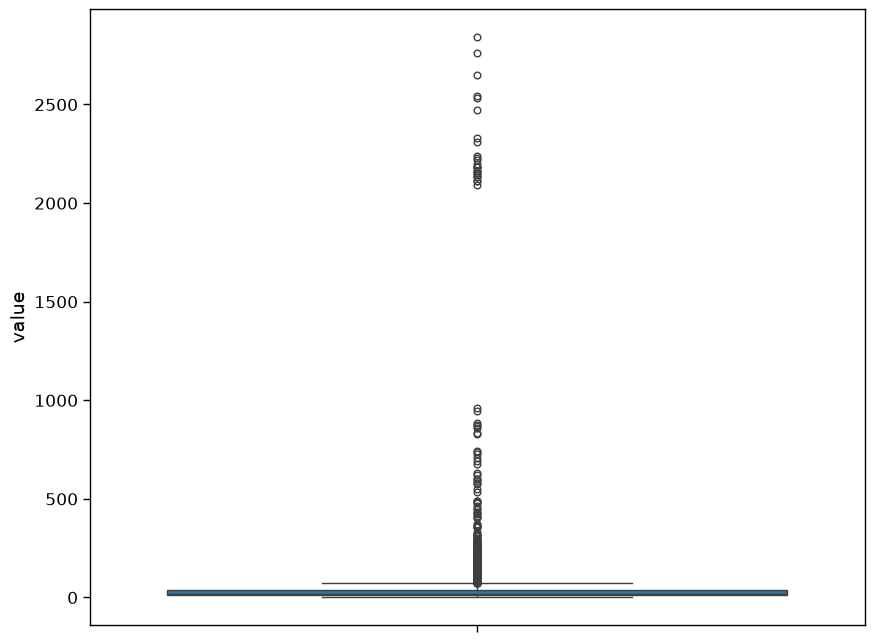

<Figure size 640x480 with 0 Axes>

In [79]:
plt.figure(figsize=(10, 8))
sns.set_context(context='paper', font_scale=1.4)
sns.boxplot(data=clean_df, y='value')
plt.show()
plt.tight_layout()

че за бред


In [87]:
(clean_df['value'] > 300).sum()

np.int64(74)

everything that is above 300 its just impossible in city so we consider it as a mistake of sensors

In [90]:
clean_df = clean_df[clean_df['value'] <= 300]
len(clean_df)


9411

In [91]:
clean_df.sample(3)

,value,location_name,flagInfo.hasFlags,summary.min,summary.q02,summary.q25,summary.median,summary.q75,summary.q98,summary.max,summary.avg,summary.sd,coverage.expectedCount,coverage.expectedInterval,coverage.observedCount,coverage.observedInterval,coverage.percentComplete,coverage.percentCoverage,season
9980,25.30,№174 mektep-gimnaziya,False,1.866667,2.654417,10.041667,22.589583,35.080208,70.777083,87.020833,25.325300,19.283438,24,24:00:00,24,24:00:00,100.0,100.0,winter
3760,8.69,Iliyski trakt,False,0.000000,0.478400,5.756667,7.510000,10.207500,24.331300,25.807500,8.687051,7.052436,24,24:00:00,13,13:00:00,54.0,54.0,spring
9936,121.00,№157 mektep,False,74.929168,75.159168,87.981251,122.293751,144.470834,185.408249,188.449999,121.309896,35.072577,24,24:00:00,24,24:00:00,100.0,100.0,winter


In [94]:
# actually there left some useless stuff that i have to drop again 
clean_df = clean_df.drop(columns=['coverage.expectedCount', 'coverage.expectedInterval', 'coverage.observedInterval', 'coverage.observedCount', 'coverage.percentComplete'])

In [ ]:
clean_df[['coverage.observedCount', 'coverage.percentComplete']].corr() # almost similar so its useless too 

,coverage.observedCount,coverage.percentComplete
coverage.observedCount,1.000000,0.999927
coverage.percentComplete,0.999927,1.000000


In [93]:
(clean_df['coverage.percentComplete'] == clean_df['coverage.percentCoverage']).all()

np.True_

In [96]:
clean_df.sample(3)

,value,location_name,flagInfo.hasFlags,summary.min,summary.q02,summary.q25,summary.median,summary.q75,summary.q98,summary.max,summary.avg,summary.sd,coverage.percentCoverage,season
5006,10.0,Mamyr-3,False,3.843333,4.017000,7.335000,11.386667,12.536667,15.340667,16.730000,10.016706,3.548461,88.0,summer
9398,17.9,Qapparov köşesı (akbota.info),False,6.176708,6.339606,12.360094,17.984792,21.469562,29.304128,30.391875,17.874054,6.998665,100.0,spring
983,16.6,Kokzhiyek-63,False,10.572500,10.689517,11.168750,12.278333,20.119375,39.002550,46.310000,16.647731,8.770884,75.0,spring


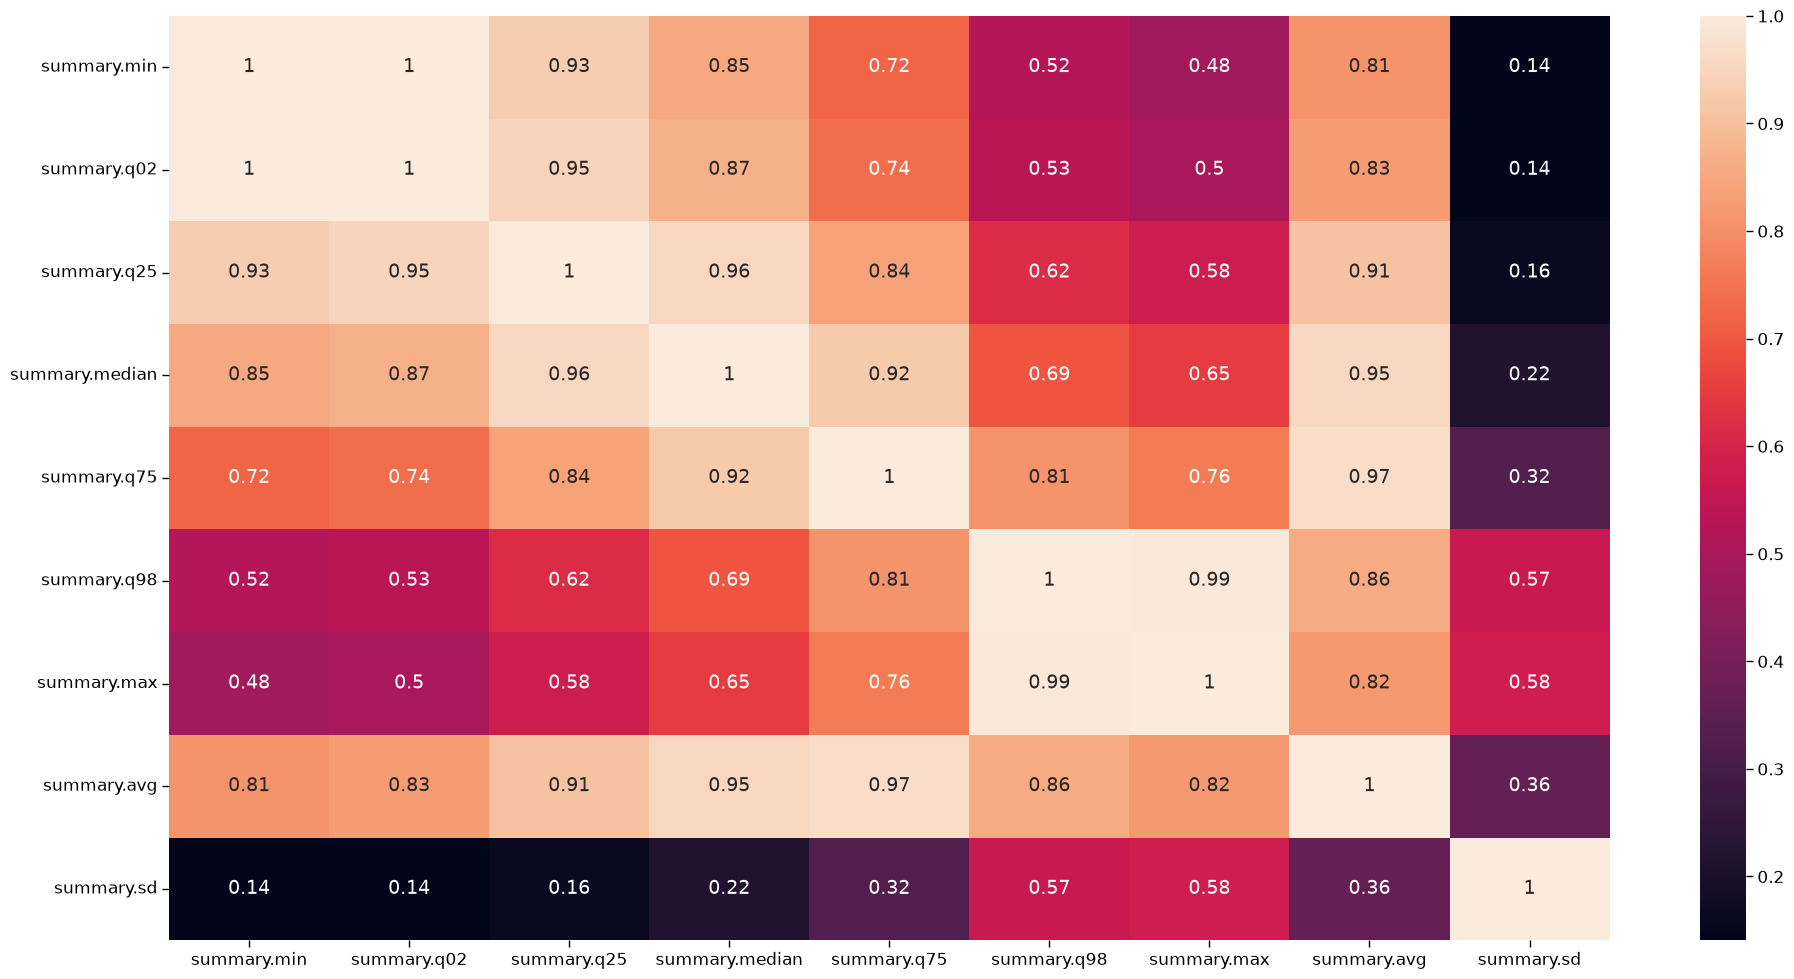

In [99]:
# but im yk kinda scared of summary things it will bother ridge 
corr = clean_df[['summary.min','summary.q02','summary.q25',
                  'summary.median','summary.q75','summary.q98',
                  'summary.max','summary.avg','summary.sd']].corr()
plt.figure(figsize=(20,10))
sns.heatmap(corr, annot=True)
plt.tight_layout()

In [100]:
# okay one more drop 
clean_df = clean_df.drop(columns=['summary.q02', 'summary.q98', 'summary.q25', 'summary.median'])

In [101]:
clean_df

,value,location_name,flagInfo.hasFlags,summary.min,summary.q75,summary.max,summary.avg,summary.sd,coverage.percentCoverage,season
0,91.5,Almaty,False,12.000000,141.000000,301.000000,91.478261,61.092826,96.0,winter
1,23.3,Almaty,False,10.000000,25.000000,66.000000,23.291667,1.500000,100.0,winter
2,73.0,Almaty,False,8.000000,122.500000,154.000000,73.041667,1.414214,100.0,winter
3,52.7,Almaty,False,16.000000,68.000000,77.000000,52.708333,14.988885,100.0,winter
4,30.2,Almaty,False,11.000000,35.000000,75.000000,30.208333,4.123106,100.0,winter
...,...,...,...,...,...,...,...,...,...,...
10504,133.0,Duman 2 (Mercur Grad),False,89.195834,164.743183,239.480000,132.993764,48.004945,96.0,winter
10505,181.0,Duman 2 (Mercur Grad),False,144.408334,187.058037,225.683334,180.973195,18.966318,100.0,winter
10506,62.3,Duman 2 (Mercur Grad),False,21.950000,70.948959,148.008334,62.254144,37.262618,83.0,winter
10507,86.0,Duman 2 (Mercur Grad),False,8.843750,148.448070,224.099999,85.968124,68.274598,92.0,winter


In [103]:
clean_df['location_name'].value_counts()

location_name
Qapparov köşesı (akbota.info)    339
Kokzhiyek-63                     332
Elaman 105 St.                   331
Kotelnikova St.                  330
Almaty                           321
                                ... 
№184 mektep                       10
№107 mektep                       10
School 186                         9
Duman 2 (Mercur Grad)              9
№163 litsei                        8
Name: count, Length: 118, dtype: int64

In [104]:
c = clean_df.copy()

In [ ]:
def season_label_encoder(x):
    if x == 'summer':
        return 0
    elif x == 'summer':
        return 1
    elif x == 'summer':
        return 2
    else:
        return 3
 

clean_df['season'] = clean_df['season'].apply(season_label_encoder)

In [117]:
clean_df.sample(3)

,value,location_name,flagInfo.hasFlags,summary.min,summary.q75,summary.max,summary.avg,summary.sd,coverage.percentCoverage,season
517,19.2,CHP,False,12.866667,22.056250,34.9175,19.165583,5.748039,83.0,0
3369,119.0,KBTU,False,80.900000,142.298333,165.5900,118.748690,31.373054,58.0,3
8274,15.0,Zhetysu 47,False,0.000000,19.581250,49.1100,15.027870,11.201509,75.0,3


In [121]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
clean_df['flagInfo.hasFlags'] = le.fit_transform(clean_df['flagInfo.hasFlags'])

In [ ]:
# okay now we have to figure out encoding(), normalization/standartization, 


In [122]:
clean_df

,value,location_name,flagInfo.hasFlags,summary.min,summary.q75,summary.max,summary.avg,summary.sd,coverage.percentCoverage,season
0,91.5,Almaty,0,12.000000,141.000000,301.000000,91.478261,61.092826,96.0,3
1,23.3,Almaty,0,10.000000,25.000000,66.000000,23.291667,1.500000,100.0,3
2,73.0,Almaty,0,8.000000,122.500000,154.000000,73.041667,1.414214,100.0,3
3,52.7,Almaty,0,16.000000,68.000000,77.000000,52.708333,14.988885,100.0,3
4,30.2,Almaty,0,11.000000,35.000000,75.000000,30.208333,4.123106,100.0,3
...,...,...,...,...,...,...,...,...,...,...
10504,133.0,Duman 2 (Mercur Grad),0,89.195834,164.743183,239.480000,132.993764,48.004945,96.0,3
10505,181.0,Duman 2 (Mercur Grad),0,144.408334,187.058037,225.683334,180.973195,18.966318,100.0,3
10506,62.3,Duman 2 (Mercur Grad),0,21.950000,70.948959,148.008334,62.254144,37.262618,83.0,3
10507,86.0,Duman 2 (Mercur Grad),0,8.843750,148.448070,224.099999,85.968124,68.274598,92.0,3
